STARNet workflows have two main parts: model training, followed by gene regulatory network (GRN) module inference. The inferred GRNs can then be reused for downstream analyses such as spatial trajectory inference, GWAS interpretation, and drug response analysis.

This tutorial uses paired spatial RNA and ATAC data from human hippocampus. It walks through STARNet training, GRN inference, module scoring, and spatial visualization. The trained spot and gene embeddings are reused as inputs for GRN inference.

In [1]:
import warnings
import os
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

import scanpy as sc
import anndata as ad
import STARNet as ST
import pickle

## Stage 1: Model Training and GRN Inference

### Read data

This tutorial uses the human hippocampus dataset. Download the tutorial data from [Links to Data Folder](https://drive.google.com/drive/folders/1obqewcAAvcUi8WOhqomKDo7BO_GncNvP?usp=sharing), then place the `Drive` folder next to this notebook so paths such as `Drive/Datasets/Human_Hippocampus/...` resolve correctly. You can download only the files used here or the full data folder.

In [2]:
adata_rna = sc.read_h5ad("Drive/Datasets/Human_Hippocampus/Raw_Data/adata_rna.h5ad")
adata_atac = sc.read_h5ad("Drive/Datasets/Human_Hippocampus/Raw_Data/adata_atac.h5ad")

Here, we create a `ST.model.STARNet` object from the paired RNA and ATAC AnnData objects. If a GPU is available, set `device='cuda:N'` to choose the GPU used for training.

In [3]:
starnet_obj = ST.model.STARNet(adata_rna, adata_atac)

Next, `preprocess()` prepares the paired multi-omics data for model training. This step performs quality control, selects highly variable genes and peaks, normalizes the data, and constructs the required scRNA, scATAC, cell-neighbor, and peak-to-gene graphs.

In [4]:
starnet_obj.preprocess()


Step 1: Data Alignment and Initialization
📄 Data Alignment Results:
   ✓ adata_rna: Dataset shape: 2500 spots × 29293 genes
   ✓ adata_atac: Dataset shape: 2500 spots × 169121 peaks
Converting adata_rna.X to csr_matrix format.
✅ Conversion complete.

Step 2: Processing RNA Data
Filtering genes: min_cells=15
Running RNA Leiden clustering (res=0.2)...

Step 3: Processing ATAC Data
Selecting top 40000 ATAC peak features.
Running ATAC Leiden clustering (res=0.2)...
Final RNA shape: (2500, 17046)
Final ATAC shape: (2500, 40000)

Step 4: Building Heterogeneous HyperGraph
🧬 RNA graph nodes prepared: 17046 genes
🧩 ATAC graph nodes prepared: 40000 peaks
Building Dual-Modality Spot-Spot matrices...
Using 'leiden' clusters from obs.
Constructed dual-modality matrix for K=3.
Constructed dual-modality matrix for K=4.
Constructed dual-modality matrix for K=8.
 ✅ Graph data moved to device: cuda


We then train STARNet for 600 epochs, which is the recommended setting for these tutorial datasets. Training stores the spot/cell embedding in `adata_rna.obs` and the gene embedding in `adata_rna.uns` for later GRN inference.

In [5]:
starnet_obj.train(epochs=600, eval_every=600)


🔍 Step 1: STARNet Model Initialization and Configuration
📄 Model Parameters:
   ✓ Hidden Dim: 128
   ✓ Output Dim: 128
   ✓ Device: cuda
   ✓ SSL Num Neg: 10240


INFO: GPU available: True (cuda), used: True
2026-05-11 03:03:53 - INFO - GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-11 03:03:53 - INFO - TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-11 03:03:53 - INFO - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090 D') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/

Lightning model built with ComplexConv_v4 architecture.

🔍 Step 2: Starting STARNet Training Loop
📄 Training Configuration:
   ✓ Max Epochs           : 600
   ✓ Device               : cuda:0
   ✓ Evaluation Every     : 600 epochs
   ✓ Checkpointing        : True
   ✓ TensorBoard Log Dir  : ./lightning_logs/STARNet/version_7


Epoch 000/600:   0%|          | 0/600 [00:00<?, ?epoch/s]

📊 Epoch Summary: epoch=1/600, best_total_loss=6.5675
📊 Epoch Summary: epoch=600/600, best_total_loss=0.4123
Evaluating clustering using representation 'cell_embedding'...


INFO: `Trainer.fit` stopped: `max_epochs=600` reached.
2026-05-11 03:05:39 - INFO - `Trainer.fit` stopped: `max_epochs=600` reached.


📊 Training Summary:
   ✓ Completed Epochs     : 600
   ✓ Best Total Loss      : 0.4123
 ✅ Epoch-level training visualization finished.
✅ Training finished!
   ✓ TensorBoard logs saved to: ./lightning_logs/STARNet/version_7
   ✓ Checkpoints saved to: ./lightning_logs/checkpoints


Plotting clustering results...


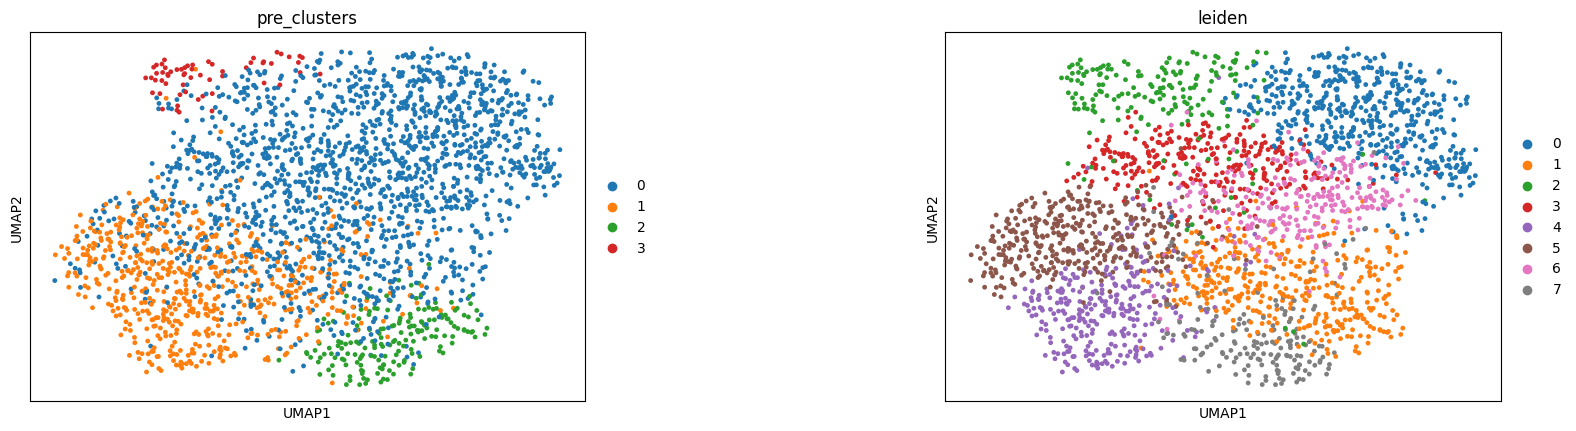

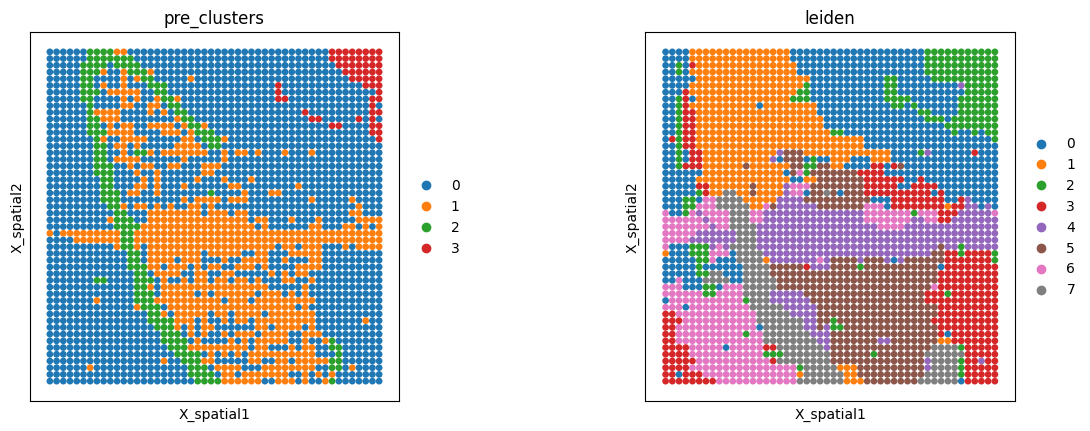

In [6]:
starnet_obj.plot_clustering_results(rep_name='cell_embedding', spot_size=1)

The trained RNA AnnData object is shown below and saved for reuse in the GRN inference steps.

In [7]:
print(f'RNA data after training: {starnet_obj.adata_rna}')
starnet_obj.adata_rna.write_h5ad("Drive/Datasets/Human_Hippocampus/Process_Data/adata_rna_trained.h5ad")

RNA data after training: AnnData object with n_obs × n_vars = 2500 × 17046
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pre_clusters'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'gene_embedding', 'pre_clusters_colors', 'leiden_colors'
    obsm: 'X_spatial', 'X_pca', 'cell_embedding', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


### Load multi-omics data

For GRN inference, you can either continue with the AnnData object trained above or load the pre-trained dataset provided with the tutorial files.

In [8]:
# Load data from the trained model or from a saved state

# optional
# adata_rna = starnet_obj.adata_rna
# adata_atac = starnet_obj.adata_atac

adata_rna = sc.read_h5ad('Drive/Datasets/Human_Hippocampus/Process_Data/adata_rna_trained.h5ad')
adata_rna_raw = sc.read_h5ad("Drive/Datasets/Human_Hippocampus/Raw_Data/adata_rna.h5ad")
adata_atac = sc.read_h5ad("Drive/Datasets/Human_Hippocampus/Raw_Data/adata_atac.h5ad")

Before GRN inference, we add the raw RNA counts to the `count` layer because the downstream GRN calculations use raw count values.

RNA data info:
AnnData object with n_obs × n_vars = 2500 × 17046
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pre_clusters'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'gene_embedding', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'pre_clusters_colors', 'umap'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'cell_embedding'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
ATAC data info:
AnnData object with n_obs × n_vars = 2500 × 169121
    obs: 'n_fragment', 'frac

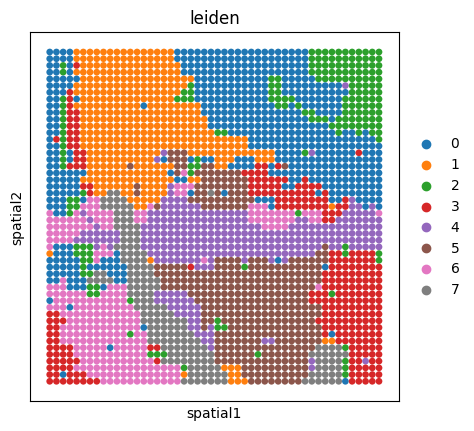

In [9]:
gene_embedding = ad.AnnData(adata_rna.uns['gene_embedding'])
gene_embedding.obs_names = adata_rna.var_names.tolist()
adata_rna.uns['gene_embedding'] = gene_embedding

adata_rna.layers['counts'] = adata_rna_raw[:,adata_rna.var_names].X
adata_atac.layers['counts'] = adata_atac.X

# Preprocess
adata_rna.obs_names = [obs_names.split('-')[0] for obs_names in adata_rna.obs_names]
adata_atac.obs_names = [obs_names.split('-')[0] for obs_names in adata_atac.obs_names]

print(f'RNA data info:\n{adata_rna}')
print(f'ATAC data info:\n{adata_atac}')

sc.pl.spatial(adata_rna,color='leiden',spot_size=1)

### Load genomic reference files and infer GRNs

With the multi-omics data prepared, we load the genomic reference folder and infer GRNs. `use_rep` selects the embedding used to group similar spots/cells. `pvalue_regulatory=0.2` controls the p-value threshold for candidate cis-regulatory links, and `moranI_threshold=0.01` keeps transcription factors with Moran's I scores above the threshold as spatially variable regulators.

In [10]:
genomic_data_pathway = 'Drive/Datasets/Reference/human_v42'
adata_rna = ST.grn.infer_grn_from_multiomics(adata_rna,
                                             adata_atac,
                                             genomic_data_pathway,
                                             use_rep='cell_embedding',
                                             pvalue_regulatory=0.2,
                                             moranI_threshold=0.01,
                                             n_jobs=5)


🧬 Starting Spatially Specific GRN Inference Pipeline in STARNet

🔍 Step 1: Identifying Genomic Reference Files
📄 Target Directory: Drive/Datasets/Reference/human_v42
✅ Genomic files identified and validated.
📄 File Discovery Results:
   ✓ Motif File        : cisBP_human.meme
   ✓ Genome Fasta      : GRCh38.primary_assembly.genome.fa
   ✓ Annotation (GFF)  : gencode.v42.basic.annotation.gff3
   ✓ Annotation (GTF)  : gencode.v42.annotation.gtf
 ✅ Reference genome and annotation paths successfully loaded.

🔍 Step 2: Peak GC Content Analysis
 ⚙️ Calculating GC proportion for peaks of spatial ATAC-seq data...

🔍 Step 3: Spatially Specific Transcription Factor Identification
 ⚙️ Identifying TFs with significant spatial patterns (Moran's I > 0.01)...
   ✓ Identify spatially-variable expressed TFs: 406

🔍 Step 4: Genomic Data Alignment and Formatting
✅ Genomic data preparation successful.
📄 Processed Stats:
   ✓ RNA spots/genes  : 2500 × 13919
   ✓ ATAC spots/peaks : 2500 × 169121
   ✓ Aligne

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

 ⚙️ Building kernel on cell_embedding...


...

   ✓ Generated 33 metacells.

🔍 Step 7: GRN Filtering (Stage1)
 ⚙️  Calculating correlations for 203000 interactions...
 📄 Processed Stats:
   ✓ Threshold                   : >0.2
   ✓ Initial TF-target Pairs     : 203000
   ✓ Passed TF-target Pairs    : 64682
   ✓ Removal TF-target Rate      : 68.14%
✅ Correlation filtering complete.
 ⚙️ Mapping peaks to genes (100kb around gene body)...
 📄 Processed Stats:
   ✓ Expand Range    : +/- 100,000 bp
   ✓ Initial Pairs   : 64682
   ✓ Validated Pairs : 64356
   ✓ Removal Rate    : 0.50%
✅ Peak filtering complete.

 ⚙️ Step 8: GRN Filtering using Peak-to-Gene Links (Stage2)
Loading transcripts per gene...
Preparing matrices for gene-peak associations


100%|██████████| 12907/12907 [1:14:15<00:00,  2.90it/s]


Computing peak-gene correlations


100%|██████████| 12907/12907 [2:29:08<00:00,  1.44it/s] 


 📄 Processed Stats:
    ✓ Initial Peak-to-Gene Links     : 271,875
    ✓ Significant Peak-to-Gene Links : 60,801
    ✓ Removal Rate                  : 77.64%
✅ Peak-to-Gene filtering complete.

🔍 Step 9: Parallel Motif Scanning
 ⚙️ Identify the motif corresponding to specific transcription factors...

📊 Finally Spaitally Specific GRN Inference Results:
 📊 Final Network Summary:
   ✓ Total Target Genes          : 9,424
   ✓ Total Regulatory Peaks      : 44,623
   ✓ Total TF-Target Interactions: 26,499
 ✅ Network added to .uns['grn_df'] and regulatory peaks to .uns['regulatory_peaks']


Next, we extract peak-to-gene associations from the GTF gene annotation file in the reference folder. These links connect candidate cis-regulatory elements with nearby genes, allowing STARNet to associate TF binding with spatially specific target gene expression.

In [11]:
gtf_pathway = 'Drive/Datasets/Reference/human_v42/gencode.v42.annotation.gtf'
peak2gene = ST.pp.extract_peak_gene_associations(adata_rna,gtf_file=gtf_pathway)
peak2gene.to_csv('Drive/Datasets/Human_Hippocampus/Process_Data/peak2gene.links', sep="\t", index=False)


🔗 Extracting Peak-Gene Associations for Visualization
 ⚙️ Loading GTF and aligning gene coordinates...
 ⚙️ Aggregating Peak-to-Gene links from .uns['Peak2Gene']...


 ⚙️ Parsing genomic coordinates...
 ⚙️ Calculating scores and formatting...
 📊 Association Extraction Summary:
   ✓ Total Raw Links      : 60,801
   ✓ Self-loops Removed   : 12
   ✓ Final Associations   : 60,789
 ✅ Formatting complete.


After inferring GRNs and peak-to-gene links, we score each GRN and TF module to quantify how strongly each transcription factor regulates its target genes. These scores support GRN visualization and can also be used as edge weights for downstream cell reprogramming analysis with PriciCE.

In [12]:
# Perform permutation test on all gene regulatory networks
adata_rna = ST.pp.score_all_grn(adata_rna,n_jobs=5)

# Calculate the TF module using various clustering methods and perform cauchy combination tests
adata_rna = ST.pp.score_TF_module(adata_rna,
                                  clustering_method='leiden',
                                  resolution = 2,
                                  groupby='leiden',n_jobs=5)


🧬 Calculating GRN Significance via Permutation Test
 ⚙️ Starting parallel scoring for 406 GRNs...


Scoring GRNs: 100%|██████████| 406/406 [19:13<00:00,  2.84s/it]


 ✅ Scoring complete! Results stored in:
  Full GRN score AnnData: added to .uns['grn']['adata_nlog10_pval']

🧬 TF Module Analysis: Clustering & Significance
 ⚙️ Preprocessing and running leiden clustering...
 ✅ Leiden clustering finished: 13 clusters found.
 ⚙️ Scoring 13 TF modules in parallel...


100%|██████████| 13/13 [00:22<00:00,  1.75s/it]


--------------------------------------------------
 ✨ All tasks completed successfully!
  1. TF Gene Lists:       added to .uns['TF_module']['TF_list']
  2. Target Gene Lists:   added to .uns['TF_module']['target_gene_list']
  3. Score AnnData:       added to .uns['TF_module']['nlog10_pval_ad']
  4. Cauchy Results:      added to .uns['TF_module']['cauchy_combination_test']



We save the scored GRN results as AnnData files and the TF modules as pickle files so they can be reused without repeating the full inference step.

In [13]:
adata_rna.uns['grn']['adata_nlog10_pval'].T.write_h5ad("Drive/Datasets/Human_Hippocampus/Process_Data/human_hippocampus_grn_nlog10_pval.adata")

with open('Drive/Datasets/Human_Hippocampus/Process_DataTF_module_30.pkl', 'wb') as f:
	pickle.dump(adata_rna.uns['TF_module'], f)

with open('Drive/Datasets/Human_Hippocampus/Process_DataTF_module_leiden_2.pkl', 'wb') as f:
	pickle.dump(adata_rna.uns['TF_module'], f)

### Visualize GRN modules

The following cell plots GRN module activity in spatial coordinates. The module patterns should align with spatial structure in the human hippocampus dataset.

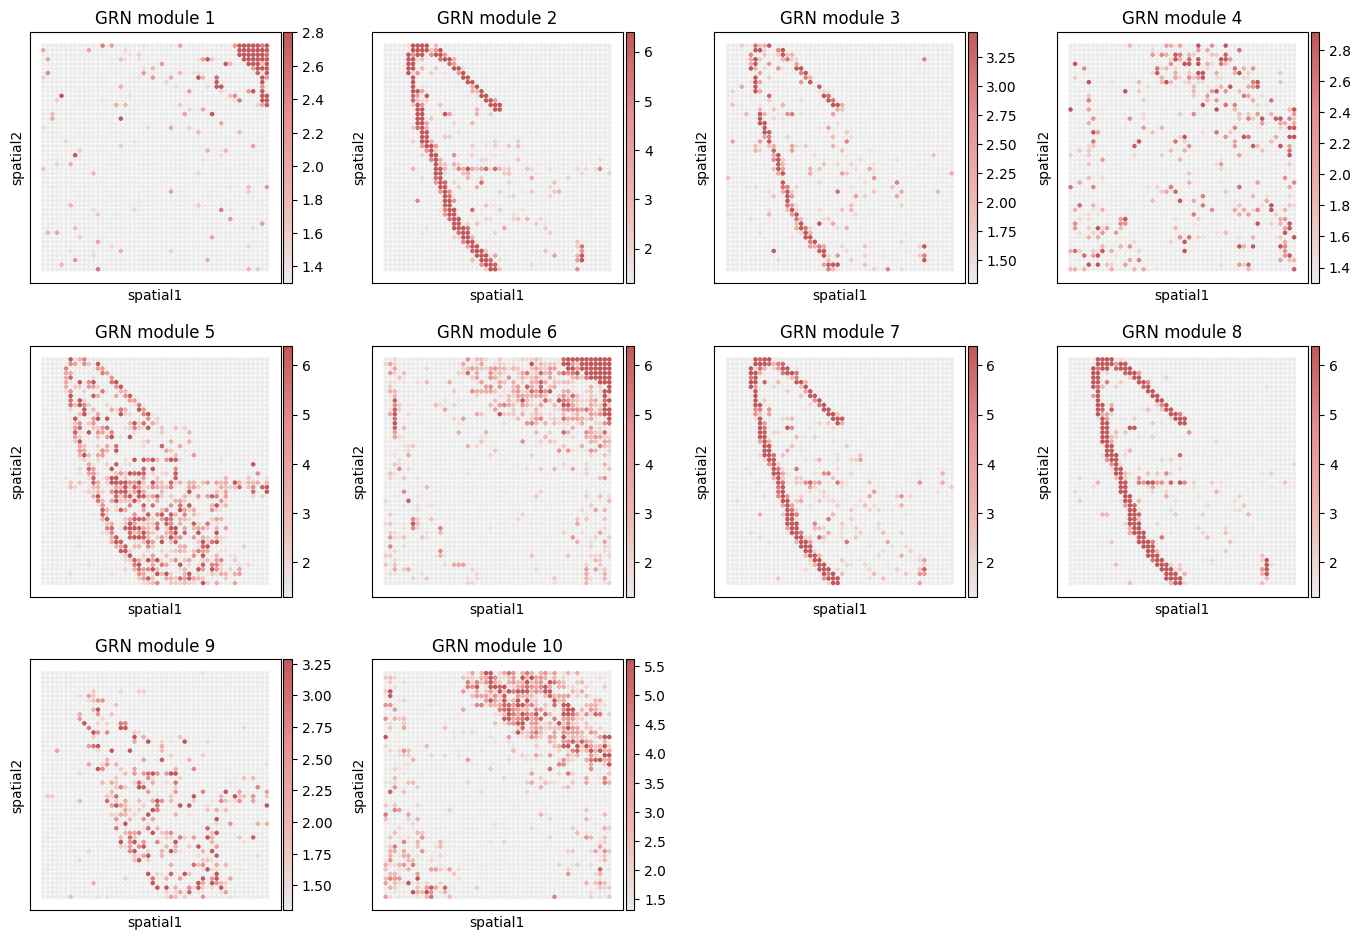

In [14]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import anndata as ad

nlog10_pval_df = adata_rna.uns['TF_module']['nlog10_pval_df']
nlog10_pval_df = nlog10_pval_df.loc[:,[str(i) for i in range(10)]]
nlog10_pval_ad = ad.AnnData(nlog10_pval_df)
nlog10_pval_ad.obsm['spatial'] = adata_rna[nlog10_pval_ad.obs_names,:].obsm['spatial']
nlog10_pval_ad.var_names = ['GRN module ' + str(int(GRM)+1) for GRM in nlog10_pval_ad.var_names]

def get_cmap_seg(colors,N=256):
        from matplotlib.colors import LinearSegmentedColormap
        # Define the colors for the gradient
        colors = np.array(colors) / 255.0
        # Create a colormap from the list of colors
        cmap_name = 'custom_cmap'
        cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=N)
        return cmap

colors = [(236, 236, 236), (237, 184, 176), (230, 145, 145), (194, 87, 89)]

with plt.rc_context({"figure.figsize": (3.5,3.5)}):
    sc.pl.spatial(nlog10_pval_ad,
                  color=nlog10_pval_ad.var_names,
               #  colorbar_loc=None,
               #  frameon=False,
                  cmap=get_cmap_seg(colors),
                  legend_loc=None,
                  spot_size=1,
                  vmax='p98',
                  vmin=-np.log10(0.05),
                  outline_width= (0.3, 0.5),
                  ncols=4,
                  hspace=0.25,
                  wspace=0.18,
                  show=False,)


In [15]:
adata_rna.write_h5ad("Drive/Datasets/Human_Hippocampus/Process_Data/adata_rna_GRN.h5ad",compression="gzip")

... storing 'chrom' as categorical
... storing 'strand' as categorical
